<a href="https://colab.research.google.com/github/fdac25/MP2/blob/main/Vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt



In [26]:
df = pd.read_csv("spastor_project_summary.csv", sep=";")
df.columns = ['project','commit','author','time','message']
df['Month'] = pd.to_datetime(df['time'], unit='s').dt.strftime('%Y-%m')
df.head()

,project,commit,author,time,message,Month
0,nlesc_mcfly,00dd7399f93919efc0efa4cfd31ce25dd1c9a3bb,Dima Muzalevskiy <dmitry.muzalevskiy@koerber.d...,1555073048,Adding restore_best_weights() option,2019-04
1,nlesc_mcfly,00e832296817aec9a79974b2242032dcdf478554,dafnevk <d.vankuppevelt@esciencecenter.nl>,1474978632,Added numpy to conda install #62\n,2016-09
2,nlesc_mcfly,00f6ec1f2e4f0f9a17b139f750a12b576ff02cb2,dafnevk <d.vankuppevelt@esciencecenter.nl>,1486546111,Changed numpy array to list so that theano als...,2017-02
3,nlesc_mcfly,010cad7afa853ae4076ec623a965b9dbfd8be263,dafnevk <d.vankuppevelt@esciencecenter.nl>,1465402151,Renamed notebook and tried regularization\n,2016-06
4,nlesc_mcfly,01559fcef61f441f953e75b3855007a30ad3c652,Dafne van Kuppevelt <d.vankuppevelt@esciencece...,1511195239,Removed some things from the travis file,2017-11


In [27]:
prj='pennylaneai_pennylane'
df1 = df[df['project']==prj]
df2 = df1.groupby('Month').size().reset_index(name='Commits')
monthly_counts = df2
monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])
full_date_range = pd.DataFrame({'time': pd.date_range(start=monthly_counts['time'].min(), end=monthly_counts['time'].max(), freq='MS')})
monthly_counts = pd.merge(full_date_range, monthly_counts, on='time', how='left').fillna(0)
monthly_counts['Month'] = monthly_counts['time'].dt.strftime('%Y-%m')
print("Cell done!")

Cell done!


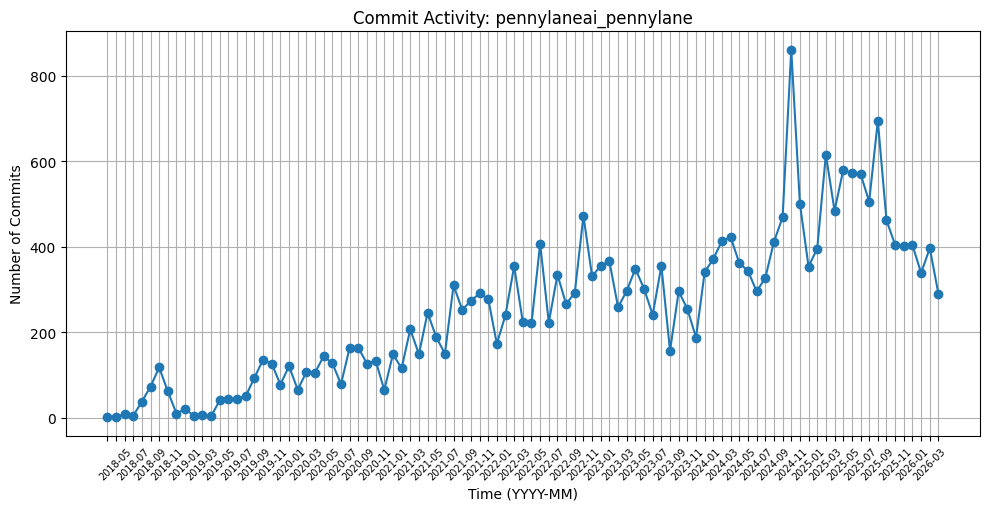

Cell done!


In [28]:
# Plot
import matplotlib.ticker as ticker

plt.figure(figsize=(10,5))
plt.plot(monthly_counts["Month"], monthly_counts["Commits"], marker="o", linestyle="-")
plt.xlabel("Time (YYYY-MM)")
plt.ylabel("Number of Commits")
plt.title("Commit Activity: "+prj)
plt.grid(True)
plt.tight_layout()
ax =  plt.gca()
for label in ax.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
plt.xticks(rotation=45, fontsize=7)
plt.savefig("spastor_timeseries_"+prj+".png", dpi=600)
plt.show()
plt.close()
print("Cell done!")

# Identify the Longest Inactivity Gap

2022-02 to 2023-04

Add all that info to netid_project_stats.csv